In [ ]:
!pip install py7zr
import py7zr
import os

# Install py7zr if not already installed

with py7zr.SevenZipFile('dataset(bigger).7z', mode='r') as z:
    z.extractall(path='/content')

#os.listdir("/content/dataset")

In [ ]:
!cp /content/drive/MyDrive/tests_unah /content/ -r

In [ ]:
import shutil

shutil.rmtree("/content/train/empty/salones")

In [ ]:
import os
import shutil

source_dir = "/content/train/full/Salon lleno/archive/images"
destination_dir = "/content/train/full"

# Ensure destination directory exists
os.makedirs(destination_dir, exist_ok=True)

# Move all contents from source to destination
for item in os.listdir(source_dir):
    s = os.path.join(source_dir, item)
    d = os.path.join(destination_dir, item)
    shutil.move(s, d)

print(f"Moved contents from '{source_dir}' to '{destination_dir}'.")

Moved contents from '/content/train/full/Salon lleno/archive/images' to '/content/train/full'.


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
data_dir = "/home/hausen/Projects/Salones_modelo/content/train/"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(0.1, 0.1)
])

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Found 3958 files belonging to 2 classes.
Using 3167 files for training.
Found 3958 files belonging to 2 classes.
Using 791 files for validation.
['empty', 'full']


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

class_weight = {
    0: 4.607,   # EMPTY
    1: 0.5609   # FULL
}

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop],
    class_weight = class_weight
)

Epoch 1/15
12/99 ━━━━━━━━━━━━━━━━━━━━ 1:15 870ms/step - accuracy: 0.7524 - loss: 0.9753

KeyboardInterrupt: 

In [7]:
import tensorflow as tf

loaded_model = tf.keras.models.load_model('modelos_salones.keras')
model = loaded_model
loaded_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,507,269 (127.82 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,180 (85.21 MB)

In [8]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Initialize lists to store true labels and predictions
y_true_list = []
y_pred_list = []

# Iterate over the validation dataset to get true labels and make predictions
for images, labels in val_ds:
    y_true_list.append(labels.numpy())
    batch_predictions = model.predict(images, verbose=0) # verbose=0 to suppress per-batch output
    y_pred_list.append(batch_predictions)

# Concatenate all batches to get final arrays
y_true = np.concatenate(y_true_list)
predictions = np.concatenate(y_pred_list)

# Convert probabilities to classes (binary classification)
y_pred = (predictions > 0.5).astype(int).flatten()

loaded_model = tf.keras.models.load_model('modelos_salones.keras')
model = loaded_model
loaded_model.summary()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names # Use the stored class_names
))


2026-03-09 16:12:13.959887: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,507,269 (127.82 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,180 (85.21 MB)

Confusion Matrix:
[[ 49  39]
 [ 21 682]]

Classification Report:
              precision    recall  f1-score   support

       empty       0.70      0.56      0.62        88
        full       0.95      0.97      0.96       703

    accuracy                           0.92       791
   macro avg       0.82      0.76      0.79       791
weighted avg       0.92      0.92      0.92       791



In [9]:
loss, acc = model.evaluate(val_ds)
print("Accuracy:", acc)

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.9241 - loss: 0.2064
Accuracy: 0.9241466522216797


# Buscar el mejor threshold


AUC: 0.9368453381611277


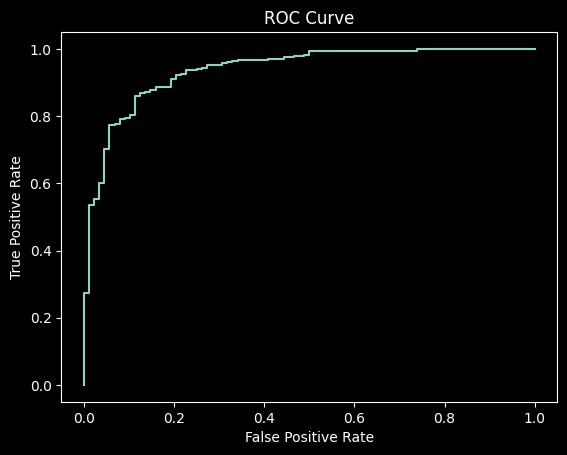

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Asegúrate de que predictions esté flatten
preds = predictions.flatten()

# Calcular ROC
fpr, tpr, thresholds = roc_curve(y_true, preds)

# Calcular AUC
auc = roc_auc_score(y_true, preds)
print("AUC:", auc)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()
#El mejor es el que esta mas cerca de (0,1)

In [11]:
import numpy as np

# Calculate the geometric mean of sensitivity and specificity
# Or, find the point closest to (0,1) on the ROC curve
# J-statistic (Youden's J statistic) is another common method: J = TPR - FPR

# Method 1: Closest to (0,1)
optimal_idx = np.argmax(tpr - fpr) # Maximizes Youden's J statistic
best_threshold = thresholds[optimal_idx]

print(f"Best Threshold (Youden's J): {best_threshold:.4f}")

# Method 2: Closest to (0,1) Euclidean distance
distances = np.sqrt(fpr**2 + (1 - tpr)**2)
closest_idx = np.argmin(distances)
best_threshold_euclidean = thresholds[closest_idx]
avg_best_threshold = (best_threshold_euclidean+best_threshold)/2

print(f"Best Threshold (Euclidean distance to (0,1)): {best_threshold_euclidean:.4f}")
print(avg_best_threshold)

Best Threshold (Youden's J): 0.7452
Best Threshold (Euclidean distance to (0,1)): 0.7452
0.745191216468811


In [ ]:
!zip -r dataset.zip /content/train

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)

img_path = "lleno2.jpg"

img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

plt.imshow(img)
plt.axis("off")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'lleno2.jpg'

In [ ]:
model.evaluate(val_ds)

25/25 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9109 - loss: 0.2096


[0.20128634572029114, 0.9241466522216797]

In [ ]:
print("Shape:", img_array.shape)
print("Min:", img_array.min())
print("Max:", img_array.max())
print("Mean:", img_array.mean())

Shape: (1, 224, 224, 3)
Min: 0.0
Max: 255.0
Mean: 106.02824


In [ ]:
prediction = model.predict(img_array)
print("Raw prediction:", prediction)
if prediction[0][0] > avg_best_threshold:
    print("Prediction: FULL classroom")
else:
    print("Prediction: EMPTY classroom")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
Raw prediction: [[0.995877]]
Prediction: FULL classroom


In [ ]:
for path in ["vacio.jpg", "vacio2.jpg"]:
    img = image.load_img(path, target_size=IMG_SIZE, color_mode="rgb")
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0][0]
    tag = "FULL classroom" if pred > avg_best_threshold else "EMPTY classroom"
    print(f"{path} → Raw prediction: {pred:.4f} → {tag}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
vacio.jpg → Raw prediction: 0.6116 → EMPTY classroom
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
vacio2.jpg → Raw prediction: 0.5397 → EMPTY classroom
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
lleno.jpeg → Raw prediction: 0.9407 → FULL classroom
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
lleno2.jpg → Raw prediction: 0.9959 → FULL classroom
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
lleno3.jpeg → Raw prediction: 0.9921 → FULL classroom
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
lleno6.jpg → Raw prediction: 0.9907 → FULL classroom
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
vacio3.jpg → Raw prediction: 0.6332 → EMPTY classroom


In [12]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

IMG_SIZE = (224, 224)
base_folder = 'tests_unah'

IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')

print(f"\nStarting recursive prediction in '{base_folder}'...")
for root, _, files in os.walk(base_folder):
    for file in files:
        if file.lower().endswith(IMAGE_EXTENSIONS):
            img_path = os.path.join(root, file)
            try:
                img = image.load_img(img_path, target_size=IMG_SIZE, color_mode="rgb")
                img_array = image.img_to_array(img)
                img_array = np.expand_dims(img_array, axis=0)

                pred = model.predict(img_array, verbose=0)[0][0]
                tag = "FULL classroom" if pred > avg_best_threshold else "EMPTY classroom"
                print(f"Image: {img_path} → Raw prediction: {pred:.4f} → {tag}")
            except Exception as e:
                print(f"Error processing {img_path}: {e}")

print("\nRecursive prediction complete.")


Starting recursive prediction in 'tests_unah'...
Image: tests_unah/6.jpg → Raw prediction: 0.5160 → EMPTY classroom
Image: tests_unah/1.jpg → Raw prediction: 0.9983 → FULL classroom
Image: tests_unah/4.jpg → Raw prediction: 0.7748 → FULL classroom
Image: tests_unah/11.jpeg → Raw prediction: 0.9844 → FULL classroom
Image: tests_unah/5.jpg → Raw prediction: 0.5733 → EMPTY classroom
Image: tests_unah/14.jpg → Raw prediction: 0.9873 → FULL classroom
Image: tests_unah/10.jpg → Raw prediction: 0.8752 → FULL classroom
Image: tests_unah/13.jpeg → Raw prediction: 0.9486 → FULL classroom
Image: tests_unah/7.jpg → Raw prediction: 0.7963 → FULL classroom
Image: tests_unah/8.jpg → Raw prediction: 0.9937 → FULL classroom
Image: tests_unah/3.jpg → Raw prediction: 0.9776 → FULL classroom
Image: tests_unah/2.jpg → Raw prediction: 0.9848 → FULL classroom
Image: tests_unah/12.jpg → Raw prediction: 0.9919 → FULL classroom
Image: tests_unah/9.jpg → Raw prediction: 0.9449 → FULL classroom

Recursive predic

# Exportar modelo

In [22]:
model.save("/home/hausen/Projects/Salones_modelo/modelos_salones.keras")

In [ ]:
from google.colab import files
files.download("modelo_salones.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>